In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/spotify_raw.csv')

print(df.head())
print(df.info())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [4]:
df.shape


(114000, 21)

In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [11]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [12]:
print(df.shape)

(113999, 20)


In [13]:
df['duration_min'] = df['duration_ms'] / 60000

In [14]:
df.to_csv('../data/spotify_cleaned.csv', index=False)

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/spotify_cleaned.csv')

Energy Level


In [16]:
df['energy_level'] = pd.cut(
    df['energy'],
    bins=[0,0.33,0.66,1],
    labels=['Low','Medium','High']
)

In [17]:
df['energy_level'].value_counts()


energy_level
High      60885
Medium    37278
Low       15835
Name: count, dtype: int64

Popularity Category

In [18]:
df['popularity_category'] = pd.cut(
    df['popularity'],
    bins=[-1,25,50,75,100],
    labels=['Low','Moderate','Popular','Hit']
)

In [19]:
df['popularity_category'].value_counts()

popularity_category
Low         44423
Moderate    41806
Popular     25356
Hit          2414
Name: count, dtype: int64

Tempo Category

In [20]:
df['tempo_category'] = pd.cut(
    df['tempo'],
    bins=[0,90,120,250],
    labels=['Slow','Medium','Fast']
)

In [21]:
df['tempo_category'].value_counts()

tempo_category
Fast      60662
Medium    36935
Slow      16245
Name: count, dtype: int64

Danceability Category

In [22]:
df['danceability_category'] = pd.cut(
    df['danceability'],
    bins=[0,0.4,0.7,1],
    labels=['Low','Medium','High']
)

In [23]:
df['danceability_category'].value_counts()

danceability_category
Medium    67307
High      27246
Low       19289
Name: count, dtype: int64

In [24]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min',
       'energy_level', 'popularity_category', 'tempo_category',
       'danceability_category'],
      dtype='str')

In [25]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,duration_min,energy_level,popularity_category,tempo_category,danceability_category
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.3580,0.715,87.917,4,acoustic,3.844433,Medium,Popular,Slow,Medium
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.1010,0.267,77.489,4,acoustic,2.493500,Low,Popular,Slow,Medium
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.1170,0.120,76.332,4,acoustic,3.513767,Medium,Popular,Slow,Medium
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.1320,0.143,181.740,3,acoustic,3.365550,Low,Popular,Fast,Low
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0829,0.167,119.949,4,acoustic,3.314217,Medium,Hit,Medium,Medium


In [26]:
df.to_csv('../data/spotify_final.csv', index=False)

Exploratory Data Analysis (EDA)

In [27]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,3.800519
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,1.788268
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.143100
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,2.901100
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,3.548433
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,4.358433
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,87.288250


Top 10 Genres

In [28]:
df['track_genre'].value_counts().head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

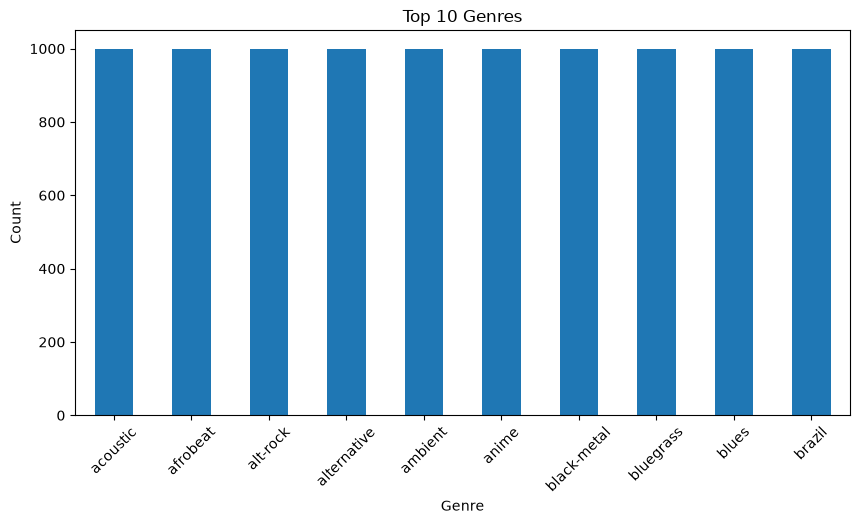

In [29]:
import matplotlib.pyplot as plt

top_genres = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Genres')
plt.xticks(rotation=45)
plt.show()

Top 10 Artists

In [30]:
df['artists'].value_counts().head(10)

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

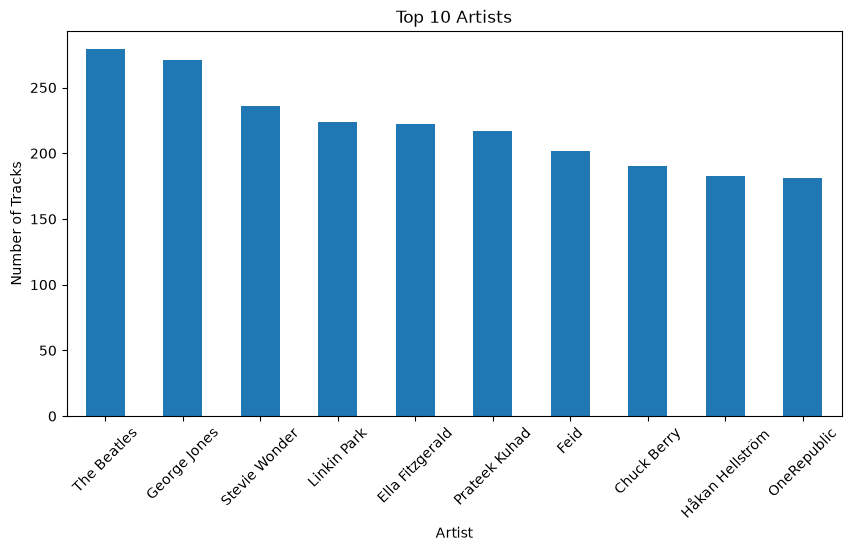

In [31]:
top_artists = df['artists'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_artists.plot(kind='bar')
plt.xlabel('Artist')
plt.ylabel('Number of Tracks')
plt.title('Top 10 Artists')
plt.xticks(rotation=45)
plt.show()

Distribution of Popularity

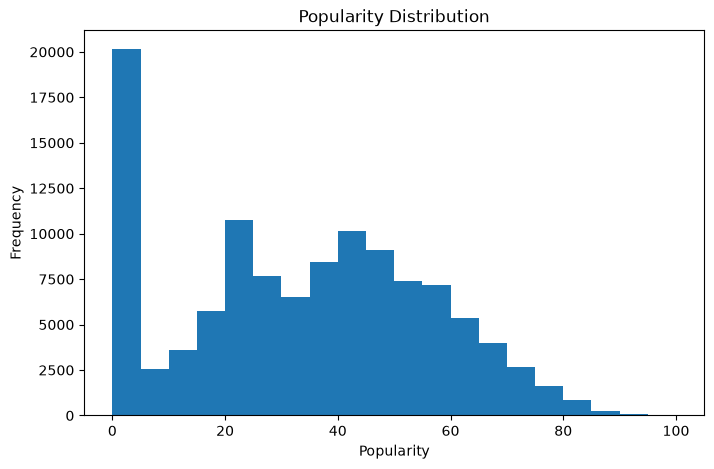

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df['popularity'], bins=20)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Popularity Distribution')
plt.show()

Energy Level Distribution

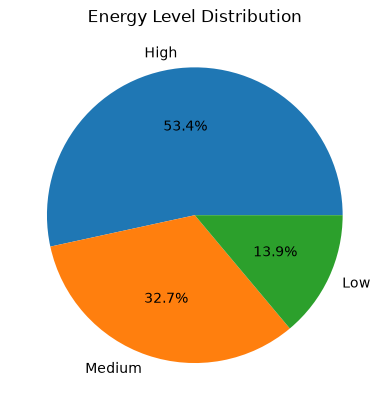

In [33]:
df['energy_level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Energy Level Distribution')
plt.ylabel('')
plt.show()

Correlation Heatmap

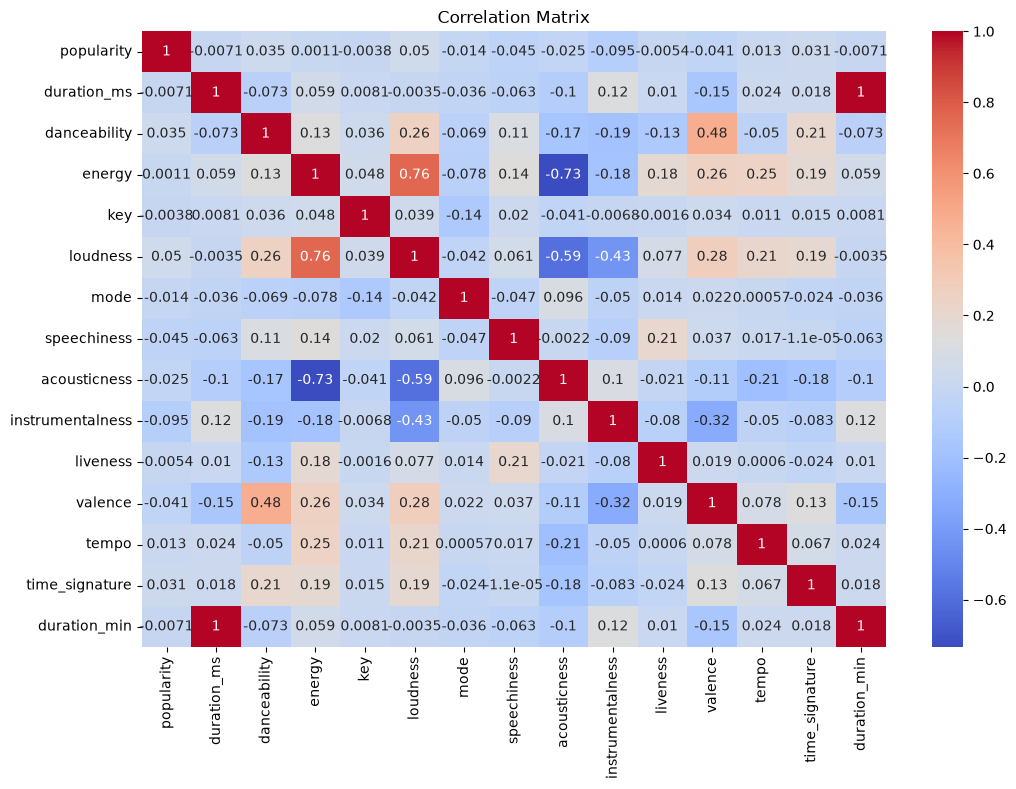

In [34]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [35]:
df.to_csv('../data/spotify_final.csv', index=False)

In [ ]:
import os

print(os.getcwd())

: 